In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("taweilo/loan-approval-classification-data")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/loan-approval-classification-data


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,RobustScaler,MinMaxScaler
import warnings
warnings.filterwarnings("ignore")


In [3]:

data= pd.read_csv(path+"/loan_data.csv")



In [4]:
data.head(10)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
5,21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,No,1
6,26.0,female,Bachelor,93471.0,1,RENT,35000.0,EDUCATION,12.42,0.37,3.0,701,No,1
7,24.0,female,High School,95550.0,5,RENT,35000.0,MEDICAL,11.11,0.37,4.0,585,No,1
8,24.0,female,Associate,100684.0,3,RENT,35000.0,PERSONAL,8.90,0.35,2.0,544,No,1
9,21.0,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3.0,640,No,1


In [5]:
data.shape

(45000, 14)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [7]:
data.isna().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
cat_val=data.select_dtypes(include="object")
cat_val.head()

,person_gender,person_education,person_home_ownership,loan_intent,previous_loan_defaults_on_file
0,female,Master,RENT,PERSONAL,No
1,female,High School,OWN,EDUCATION,Yes
2,female,High School,MORTGAGE,MEDICAL,No
3,female,Bachelor,RENT,MEDICAL,No
4,male,Master,RENT,MEDICAL,No


In [10]:
for cal in cat_val:
    print(cal,":",cat_val[cal].unique())

person_gender : ['female' 'male']
person_education : ['Master' 'High School' 'Bachelor' 'Associate' 'Doctorate']
person_home_ownership : ['RENT' 'OWN' 'MORTGAGE' 'OTHER']
loan_intent : ['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
previous_loan_defaults_on_file : ['No' 'Yes']


In [11]:
numerical_col=data.select_dtypes(include="number")
numerical_col.head()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,1
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,1
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,1
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,1


In [12]:
data.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [13]:
def outlier_visualization(df,cols):
  for col in cols:
     plt.figure(figsize=(10,5))
     plt.title(col)
     sns.boxplot(df[col])
     plt.show()

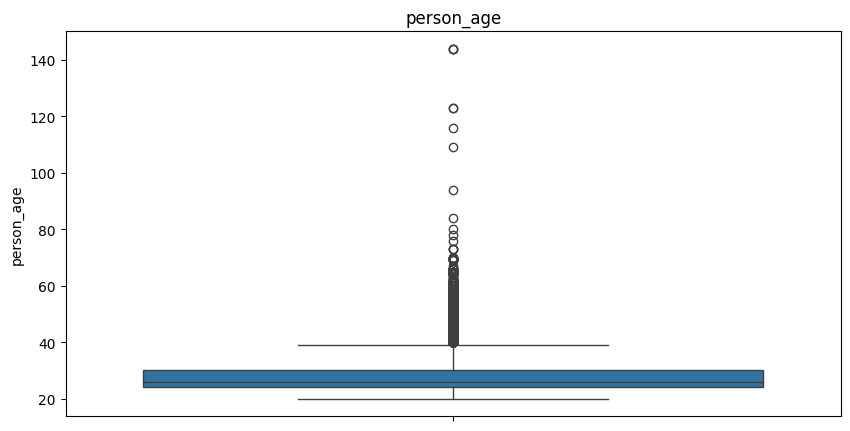

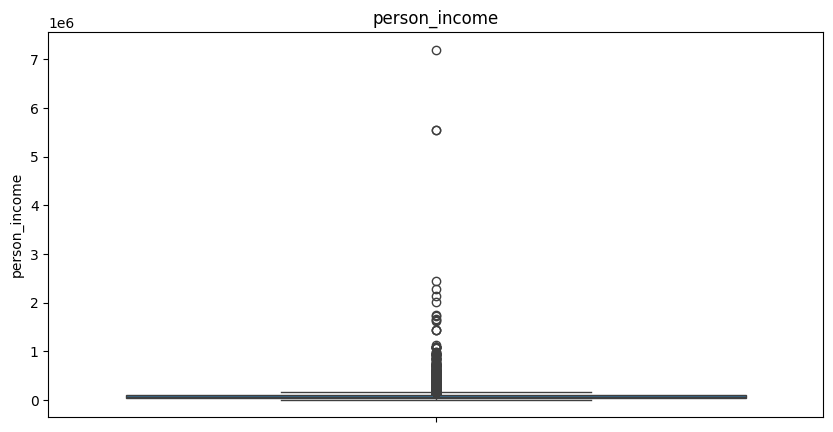

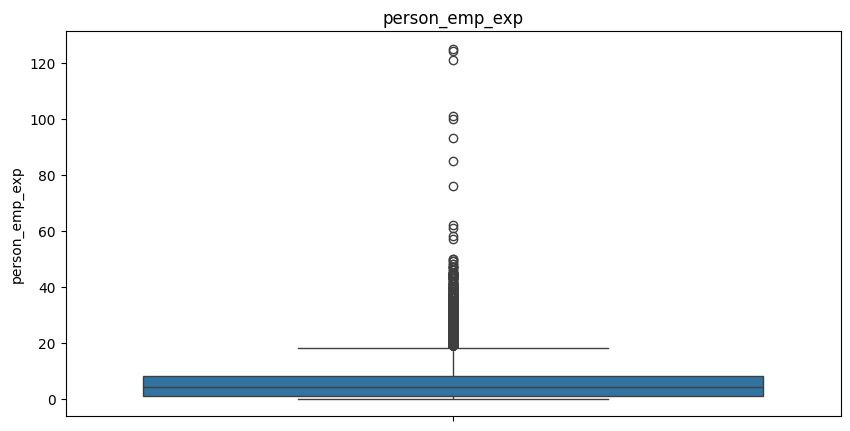

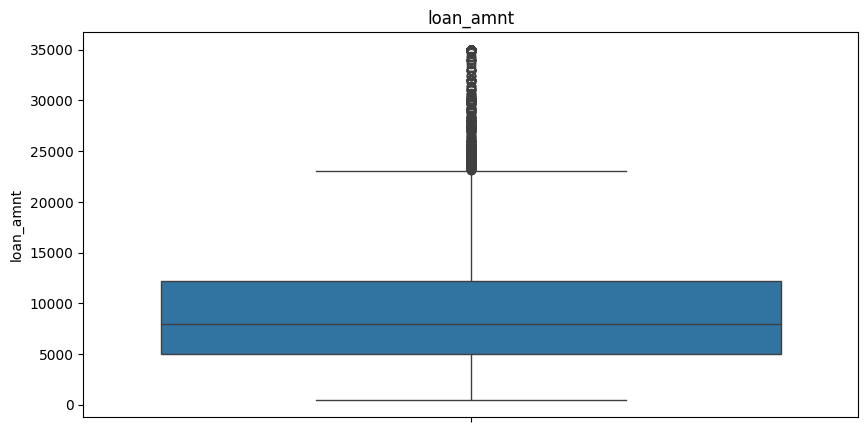

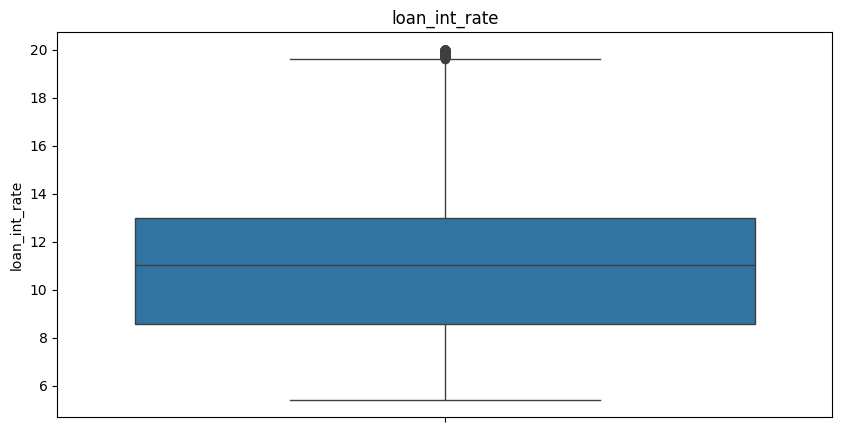

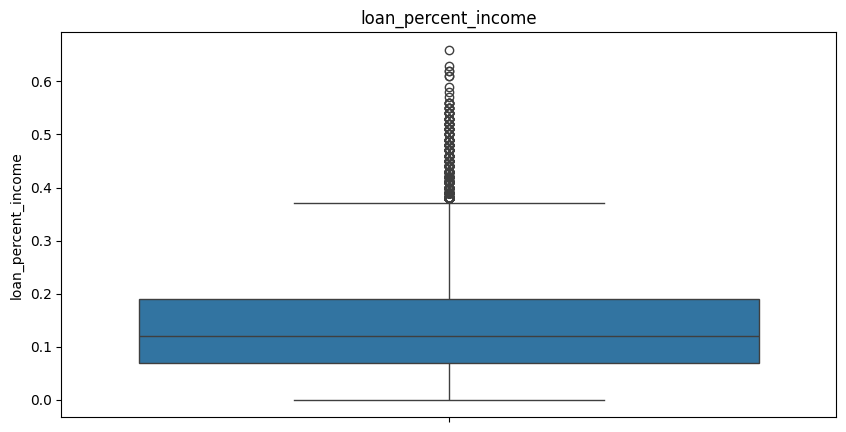

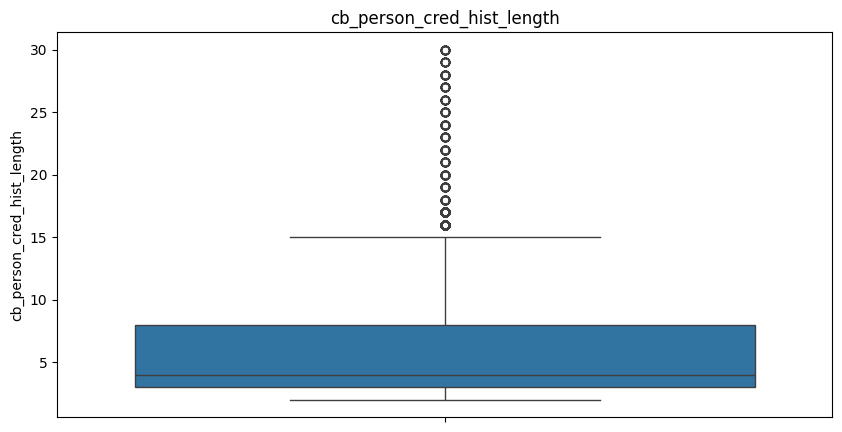

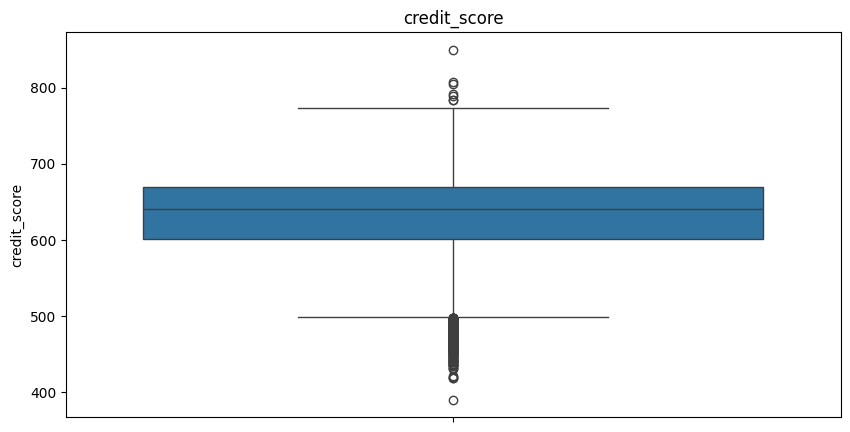

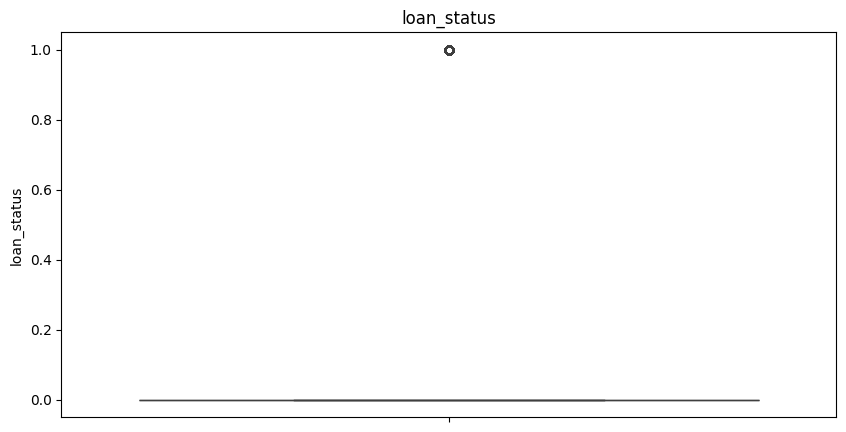

In [14]:
outlier_visualization(data,numerical_col.columns)

In [15]:
def data_hit_dist(df,cols):
  for var in cols:
    plt.figure(figsize=(10,5))
    plt.title(var)
    sns.histplot(df[var])
    plt.show()

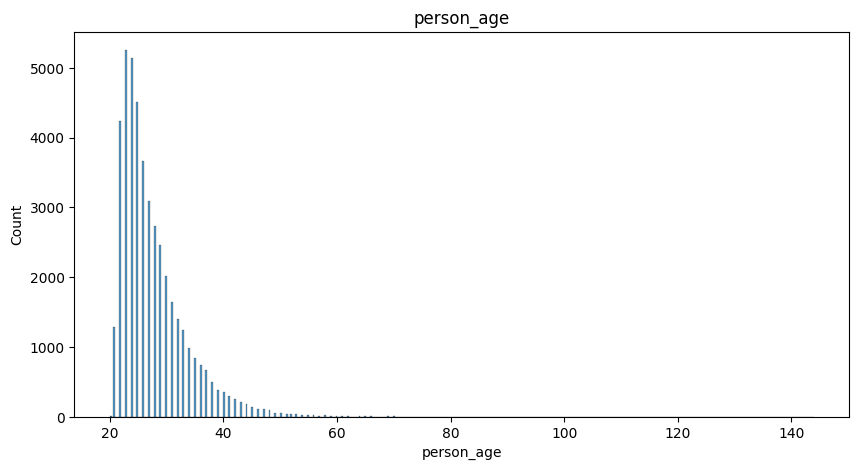

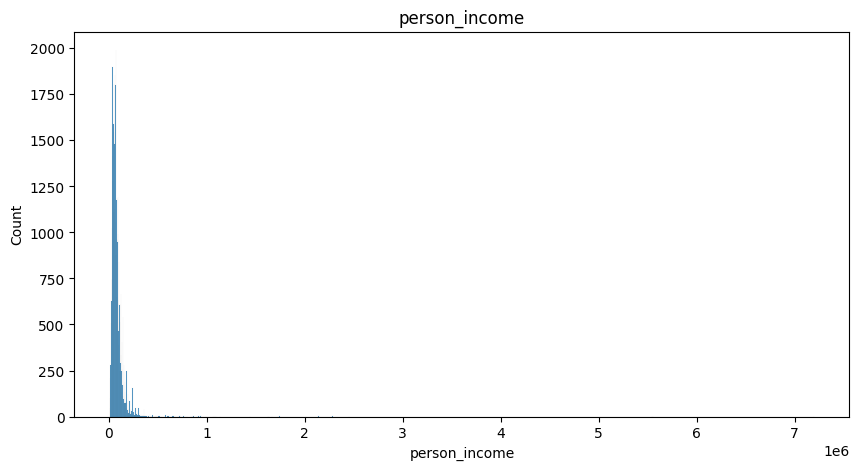

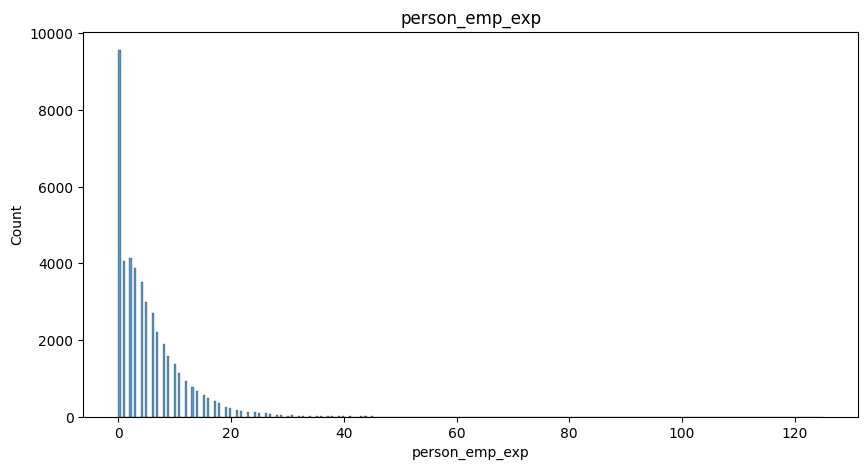

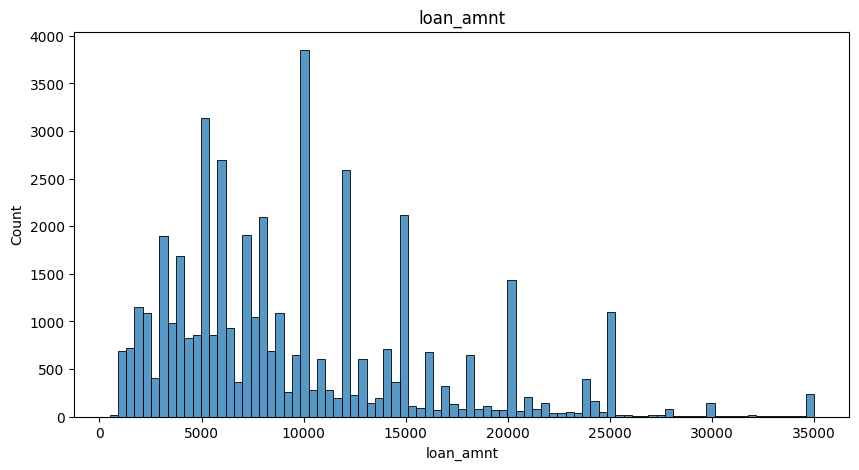

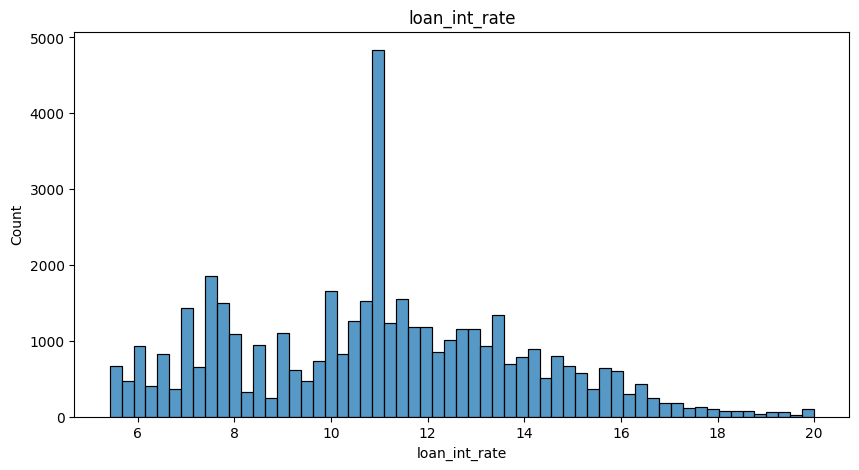

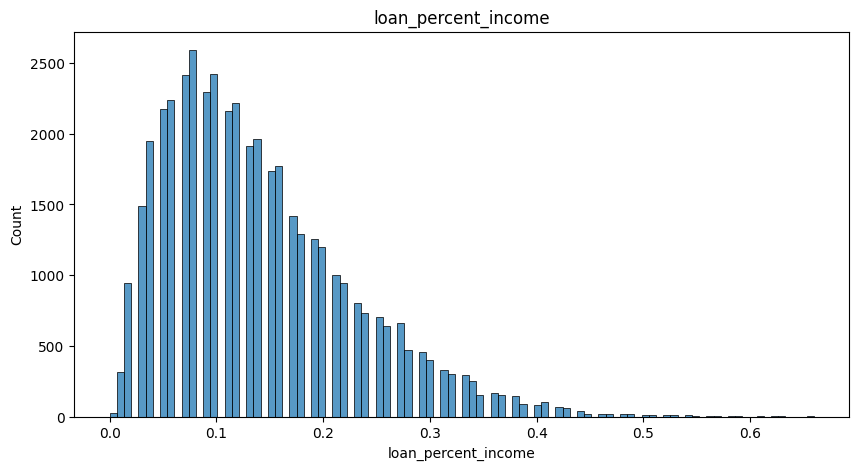

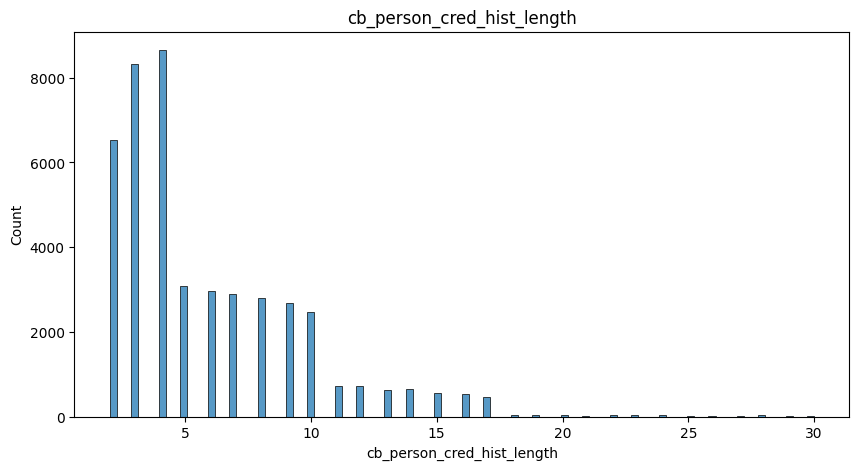

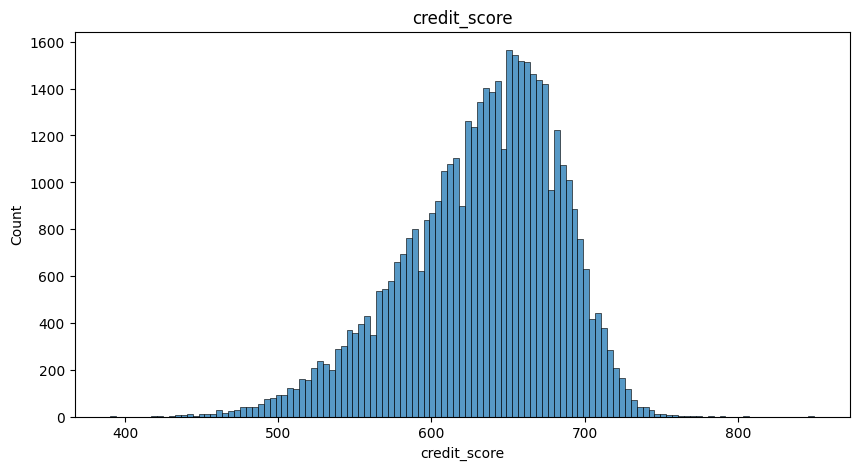

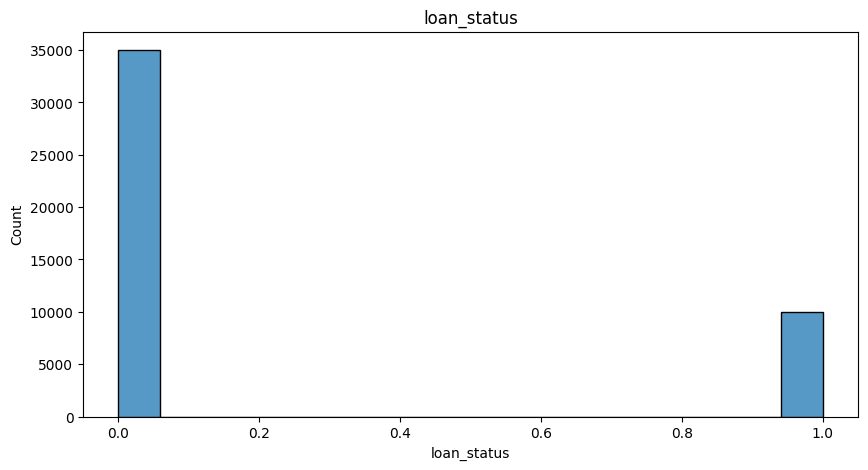

In [16]:
data_hit_dist(data,numerical_col.columns)

In [17]:
data.loan_status.value_counts()

,count
loan_status,
0,35000
1,10000


<Axes: xlabel='loan_status'>

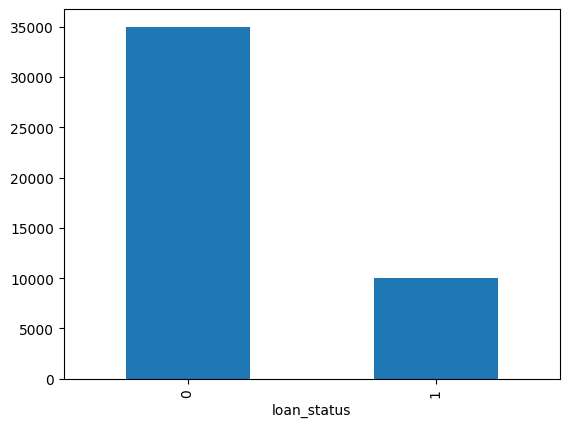

In [18]:
data.loan_status.value_counts().plot(kind="bar")

In [19]:
X=data.drop("loan_status",axis=1)
y=data["loan_status"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
X_train.shape

(36000, 13)

In [21]:
cols=X_train.select_dtypes(include="object").columns

In [22]:
col_num=X_train.select_dtypes(include=np.number).columns

In [23]:

encoder=LabelEncoder()
for col in cols:
  X_train[col]=encoder.fit_transform(X_train[col])
  X_test[col]=encoder.fit_transform(X_test[col])
X_train.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
25180,34.0,0,1,97265.0,11,0,15000.0,4,12.73,0.15,9.0,631,0
12555,25.0,1,3,72953.0,3,3,12000.0,5,11.86,0.16,4.0,659,1
29153,41.0,0,4,322597.0,18,0,24000.0,4,10.37,0.07,11.0,683,1
23838,27.0,1,0,94232.0,4,3,9600.0,1,17.14,0.10,7.0,641,0
35686,27.0,1,4,84873.0,7,3,7059.0,2,12.97,0.08,3.0,706,1


<Axes: >

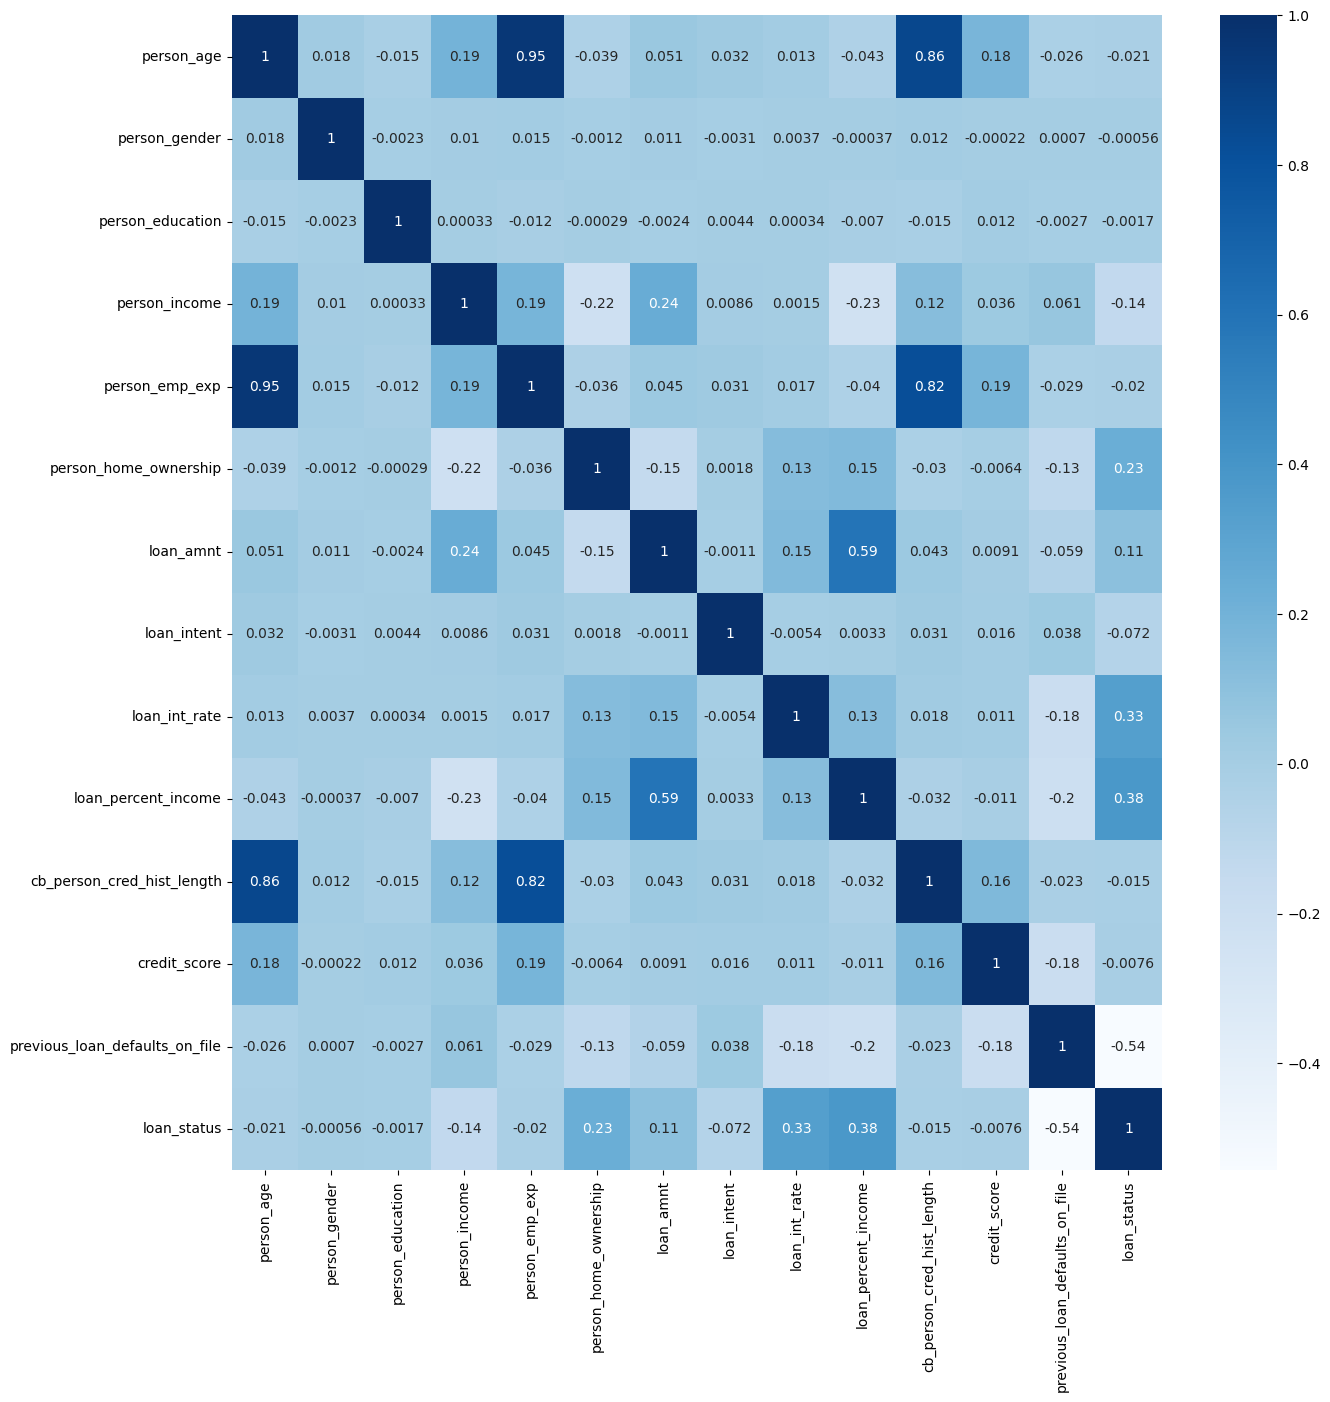

In [24]:
data1=pd.concat([X_train,y_train],axis=1)
data2=pd.concat([X_test,y_test],axis=1)
data3=pd.concat([data1,data2],axis=0)
correlation=data3.corr()
plt.figure(figsize=(15,15))
sns.heatmap(correlation,annot=True,cmap="Blues")

In [25]:
cols

Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='object')

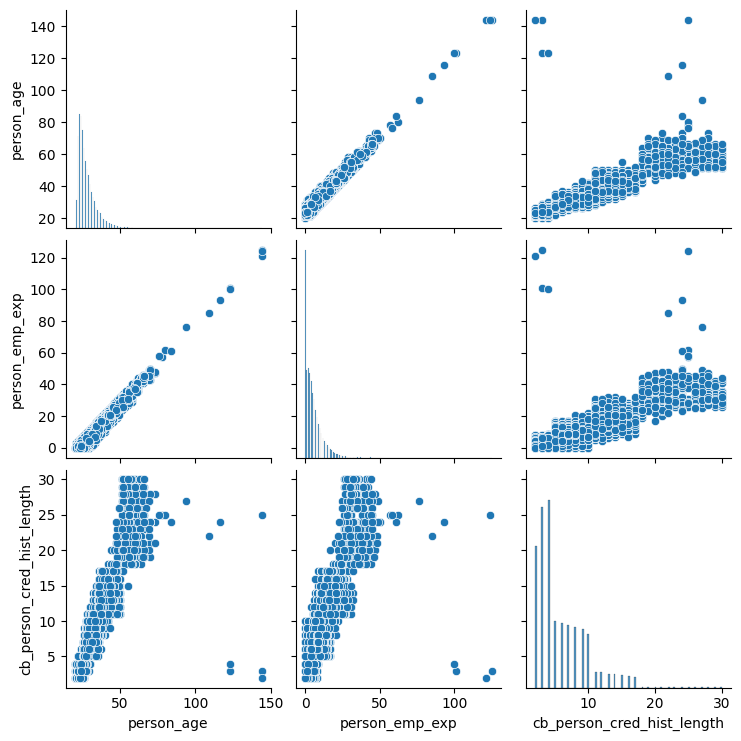

In [26]:
sns.pairplot(data[['person_age', 'person_emp_exp', 'cb_person_cred_hist_length']])



In [27]:
def outlier_handel(df,cols):
  for col in cols:
   q1=df[col].quantile(0.25)
   q3=df[col].quantile(0.75)
   IQR=q3-q1
   upper_limit=q3+(1.5*IQR)
   lower_limit=q1-(1.5*IQR)
   df[col]=df[col].clip(lower=lower_limit,upper=upper_limit)

  return df



In [28]:
outlier_handel(X_train,col_num)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
25180,34.0,0,1,97265.0,11.0,0,15000.0,4,12.73,0.15,9.0,631,0
12555,25.0,1,3,72953.0,3.0,3,12000.0,5,11.86,0.16,4.0,659,1
29153,39.0,0,4,168548.5,18.0,0,23125.0,4,10.37,0.07,11.0,683,1
23838,27.0,1,0,94232.0,4.0,3,9600.0,1,17.14,0.10,7.0,641,0
35686,27.0,1,4,84873.0,7.0,3,7059.0,2,12.97,0.08,3.0,706,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,26.0,1,3,88451.0,6.0,0,10625.0,1,6.03,0.12,4.0,559,1
44732,25.0,0,3,34772.0,3.0,0,5876.0,2,11.69,0.17,4.0,647,0
38158,33.0,0,0,58317.0,9.0,0,10707.0,5,10.74,0.18,9.0,652,1
860,26.0,1,4,168548.5,6.0,3,20000.0,0,17.99,0.11,3.0,604,0


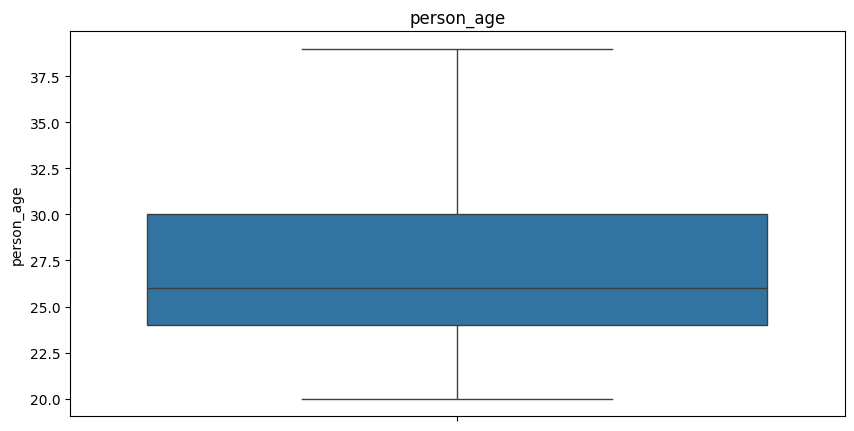

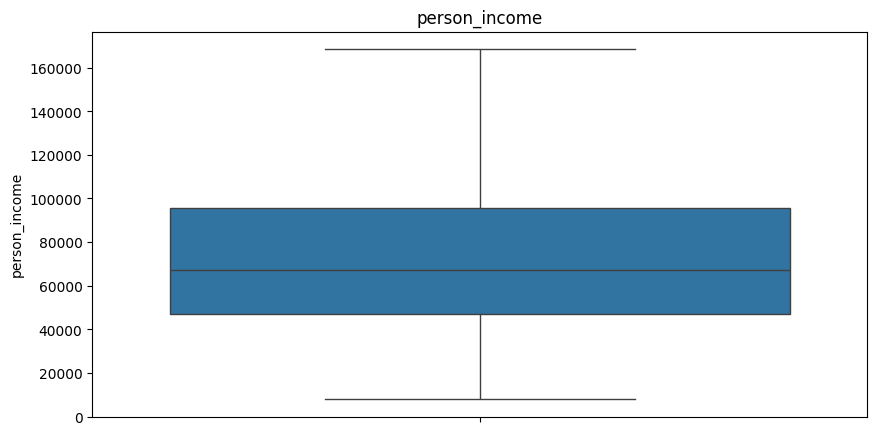

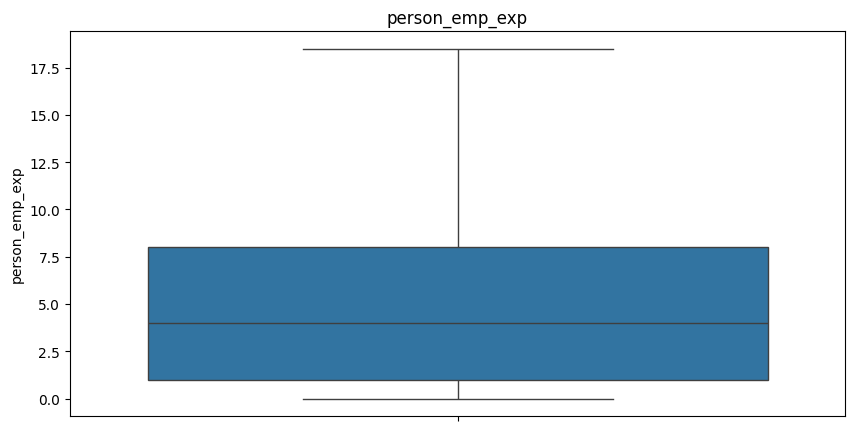

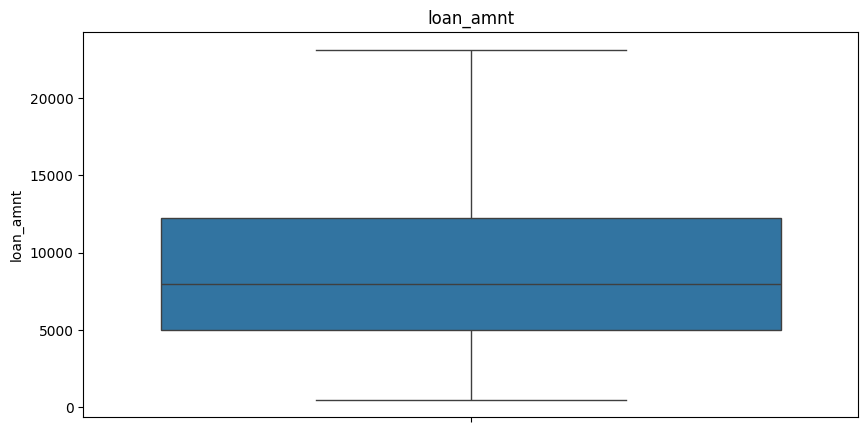

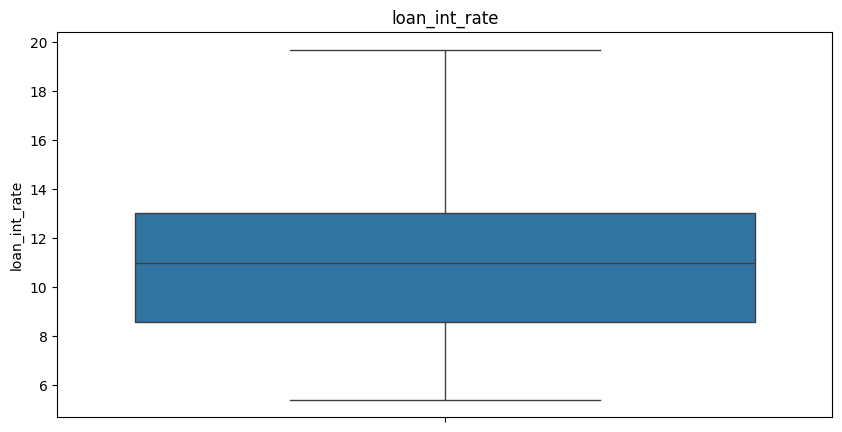

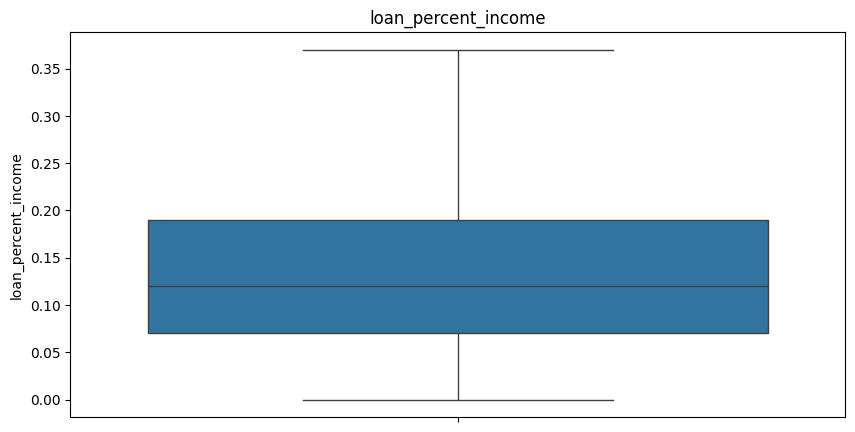

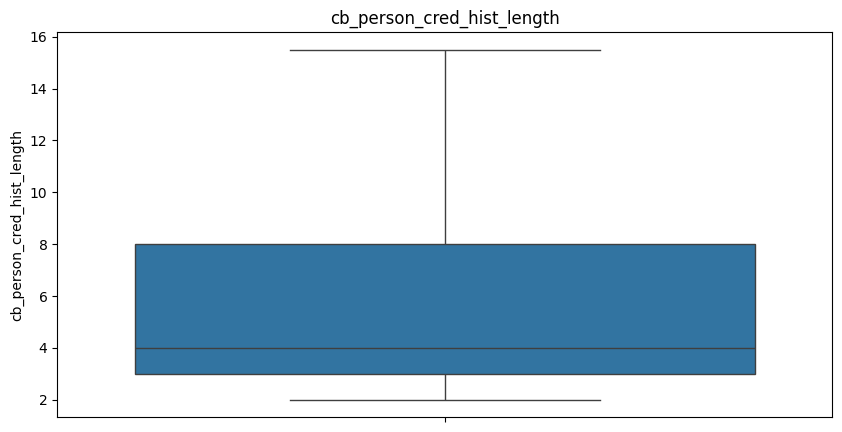

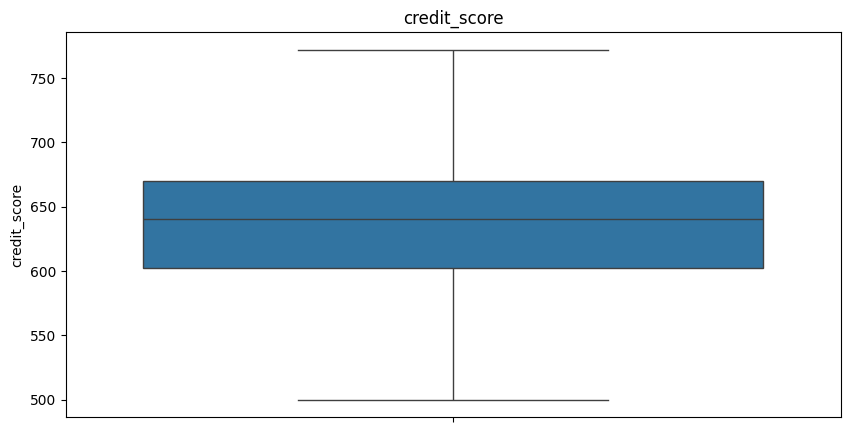

In [29]:
outlier_visualization(X_train,col_num)

In [30]:
numerical_col.drop("loan_status",axis=1,inplace=True)

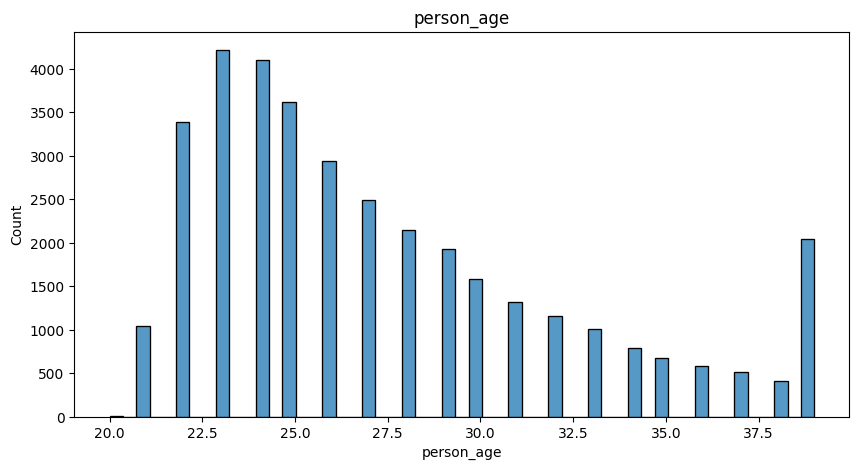

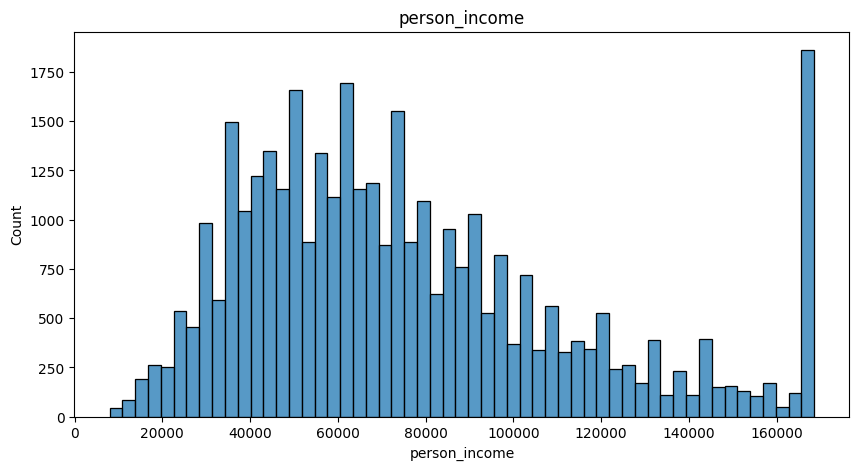

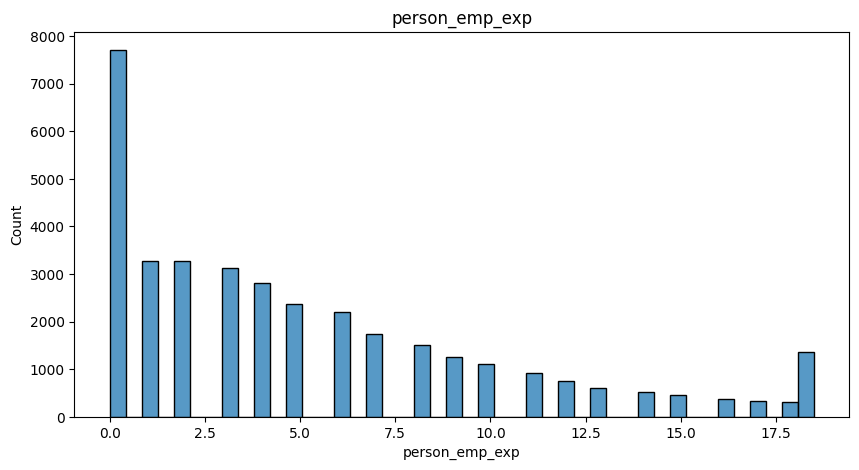

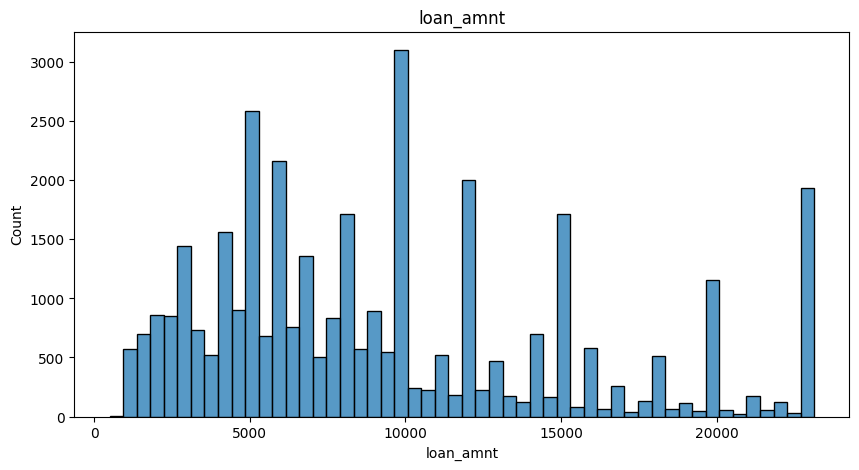

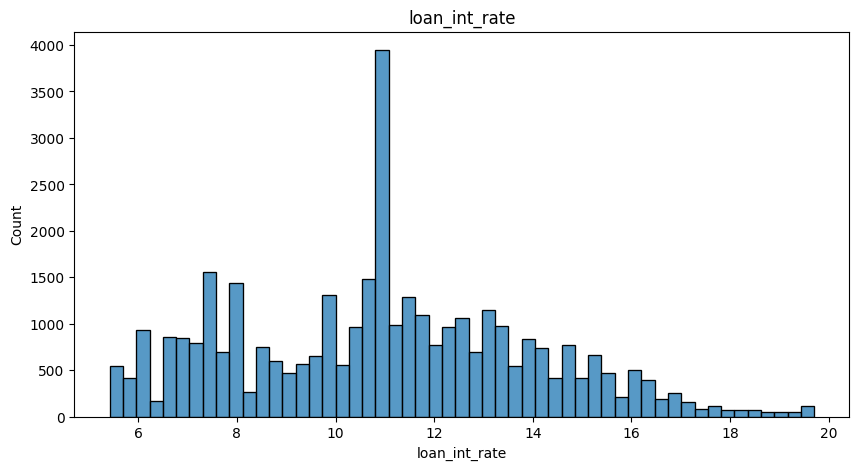

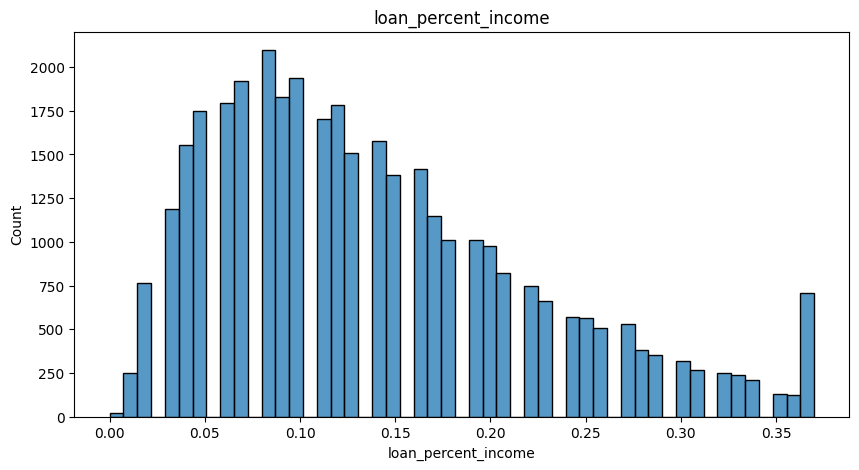

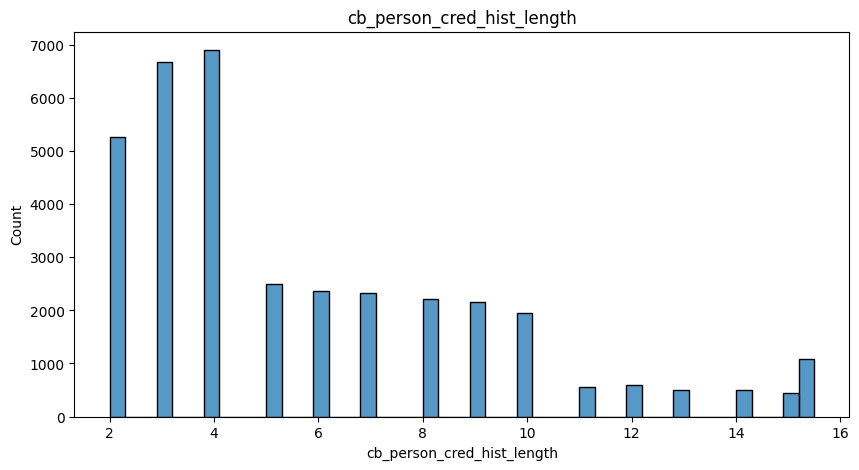

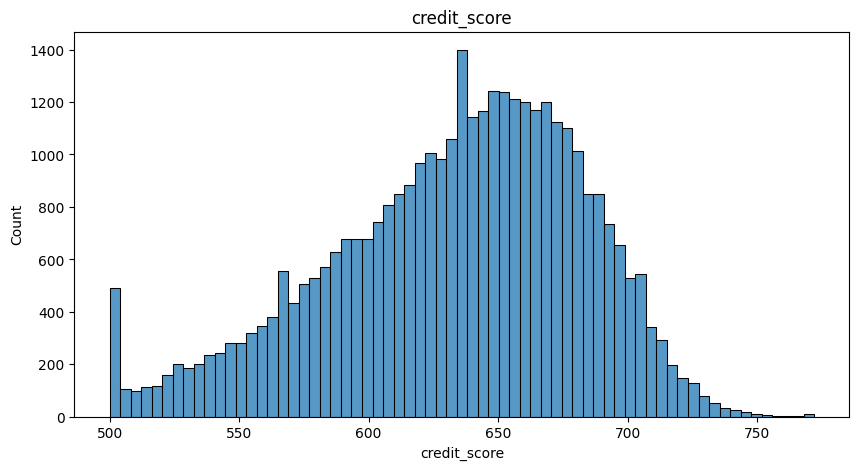

In [31]:

data_hit_dist(X_train,col_num)


In [32]:
X_train.describe()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
count,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000
mean,27.433250,0.550472,1.742778,75733.467750,5.149875,1.695500,9413.239917,2.519889,11.001504,0.138793,5.767306,632.843611,0.507028
std,4.923808,0.497453,1.479154,38093.171996,5.129590,1.440198,5836.142858,1.728509,2.987993,0.084337,3.568728,49.585375,0.499958
min,20.000000,0.000000,0.000000,8000.000000,0.000000,0.000000,500.000000,0.000000,5.420000,0.000000,2.000000,500.000000,0.000000
25%,24.000000,0.000000,0.000000,47229.750000,1.000000,0.000000,5000.000000,1.000000,8.580000,0.070000,3.000000,602.000000,0.000000
50%,26.000000,1.000000,1.000000,67092.000000,4.000000,3.000000,8000.000000,3.000000,11.010000,0.120000,4.000000,640.000000,1.000000
75%,30.000000,1.000000,3.000000,95757.250000,8.000000,3.000000,12250.000000,4.000000,13.030000,0.190000,8.000000,670.000000,1.000000
max,39.000000,1.000000,4.000000,168548.500000,18.500000,3.000000,23125.000000,5.000000,19.705000,0.370000,15.500000,772.000000,1.000000


In [33]:
def Scaling_function(X_train,X_test,scaler_class):
  scaler=scaler_class()
  X_train_scaled=scaler.fit_transform(X_train)
  X_test_scaled=scaler.transform(X_test)
  return X_train_scaled,X_test_scaled

In [35]:
Scaling_function(X_train,X_test,MinMaxScaler)

(array([[0.73684211, 0.        , 0.25      , ..., 0.51851852, 0.48161765,
         0.        ],
        [0.26315789, 1.        , 0.75      , ..., 0.14814815, 0.58455882,
         1.        ],
        [1.        , 0.        , 1.        , ..., 0.66666667, 0.67279412,
         1.        ],
        ...,
        [0.68421053, 0.        , 0.        , ..., 0.51851852, 0.55882353,
         1.        ],
        [0.31578947, 1.        , 1.        , ..., 0.07407407, 0.38235294,
         0.        ],
        [0.31578947, 0.        , 0.75      , ..., 0.07407407, 0.60294118,
         1.        ]]),
 array([[0.63157895, 1.        , 0.        , ..., 0.59259259, 0.37132353,
         0.        ],
        [0.21052632, 1.        , 0.        , ..., 0.14814815, 0.54044118,
         1.        ],
        [0.10526316, 0.        , 1.        , ..., 0.14814815, 0.77573529,
         0.        ],
        ...,
        [0.21052632, 0.        , 1.        , ..., 0.07407407, 0.41911765,
         0.        ],
        [0.9

NameError: name 'X_test_scaled' is not defined

minmax scaling

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.feature_selection import SelectKBest,chi2,RFECV
from sklearn.model_selection import GridSearchCV

In [381]:
RFECV_model=RFECV(estimator=LogisticRegression(),cv=5)
RFECV_model.fit(X_train_scaled,y_train)

y_pred_logist_RFPCv=RFECV_model.predict(X_test_scaled_pd)
print(classification_report(y_test,y_pred_logist_RFPCv))
sns.heatmap(confusion_matrix(y_test,y_pred_logist_RFPCv),annot=True,cmap="Blues",fmt="d")

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      6990
           1       0.77      0.73      0.75      2010

    accuracy                           0.89      9000
   macro avg       0.85      0.84      0.84      9000
weighted avg       0.89      0.89      0.89      9000



              precision    recall  f1-score   support

           0       0.92      0.94      0.93      6990
           1       0.77      0.73      0.75      2010

    accuracy                           0.89      9000
   macro avg       0.85      0.84      0.84      9000
weighted avg       0.89      0.89      0.89      9000



<Axes: >

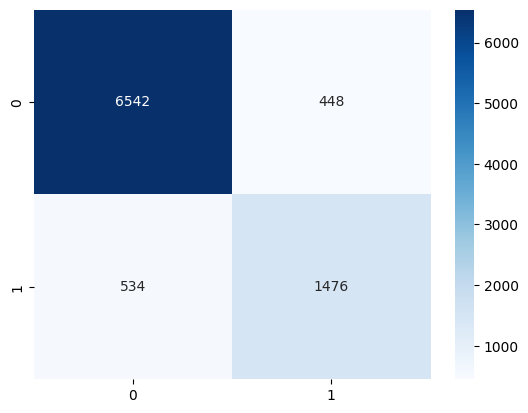

In [383]:
Scaling_function(X_train,X_test,StandardScaler)

RFECV_model=RFECV(estimator=LogisticRegression(),cv=10)
RFECV_model.fit(X_train_scaled,y_train)

y_pred_logist_RFPCv=RFECV_model.predict(X_test_scaled_pd)
print(classification_report(y_test,y_pred_logist_RFPCv))
sns.heatmap(confusion_matrix(y_test,y_pred_logist_RFPCv),annot=True,cmap="Blues",fmt="d")

In [387]:
model_SVM=SVC(kernel='linear')
RFECV_model_SVC=RFECV(estimator=model_SVM,cv=8,min_features_to_select=10)
RFECV_model_SVC.fit(X_train_scaled,y_train)
y_pred_SVM=RFECV_model_SVC.predict(X_test_scaled_pd)
print(classification_report(y_test,y_pred_SVM))
sns.heatmap(confusion_matrix(y_test,y_pred_SVM),annot=True,cmap="Blues",fmt="d")

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      6990
           1       0.77      0.73      0.75      2010

    accuracy                           0.89      9000
   macro avg       0.85      0.83      0.84      9000
weighted avg       0.89      0.89      0.89      9000



              precision    recall  f1-score   support

           0       0.95      0.97      0.96      6990
           1       0.89      0.81      0.85      2010

    accuracy                           0.93      9000
   macro avg       0.92      0.89      0.90      9000
weighted avg       0.93      0.93      0.93      9000



<Axes: >

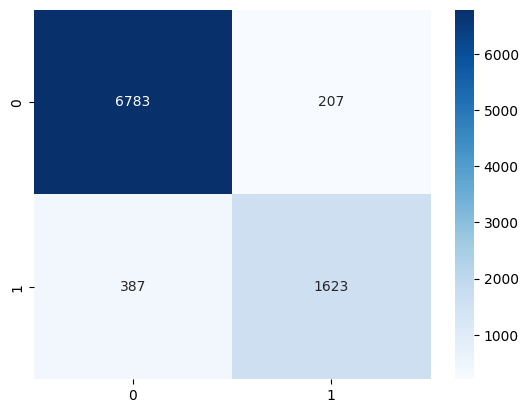

In [390]:
xgb=XGBClassifier()
model_XGB_RFE=RFECV(estimator=xgb,cv=8,min_features_to_select=10)
model_XGB_RFE.fit(X_train_scaled,y_train)
y_pred_XGB=model_XGB_RFE.predict(X_test_scaled_pd)
print(classification_report(y_test,y_pred_XGB))
sns.heatmap(confusion_matrix(y_test,y_pred_XGB),annot=True,cmap="Blues",fmt="d")

              precision    recall  f1-score   support

           0       0.94      0.97      0.95      6990
           1       0.88      0.77      0.82      2010

    accuracy                           0.93      9000
   macro avg       0.91      0.87      0.89      9000
weighted avg       0.93      0.93      0.92      9000



<Axes: >

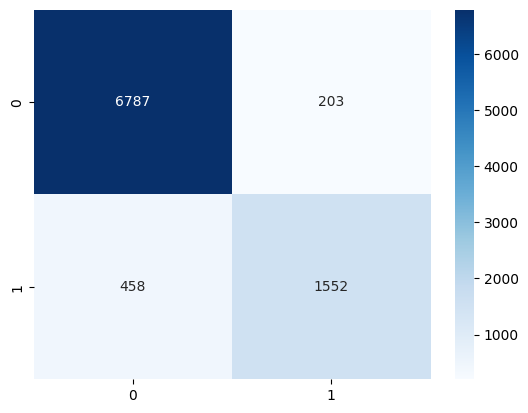

In [391]:
RandomForestClassifier=RandomForestClassifier()
model_RF=RFECV(estimator=RandomForestClassifier,cv=8,min_features_to_select=10)
model_RF.fit(X_train_scaled,y_train)
y_pred_XGB=model_RF.predict(X_test_scaled_pd)
print(classification_report(y_test,y_pred_XGB))
sns.heatmap(confusion_matrix(y_test,y_pred_XGB),annot=True,cmap="Blues",fmt="d")


              precision    recall  f1-score   support

           0       0.93      0.93      0.93      6990
           1       0.77      0.77      0.77      2010

    accuracy                           0.90      9000
   macro avg       0.85      0.85      0.85      9000
weighted avg       0.90      0.90      0.90      9000



<Axes: >

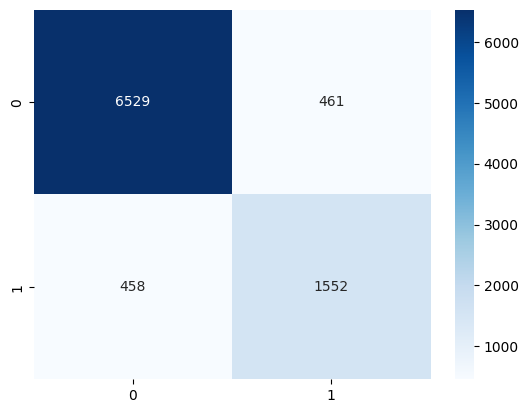

In [392]:
dt=DecisionTreeClassifier(
    random_state=42
)

model_dt_RFECV=RFECV(estimator=dt,cv=8,min_features_to_select=10)
model_dt_RFECV.fit(X_train_scaled,y_train)
y_pred_dt=model_dt_RFECV.predict(X_test_scaled_pd)
print(classification_report(y_test,y_pred_dt))
sns.heatmap(confusion_matrix(y_test,y_pred_dt),annot=True,cmap="Blues",fmt="d")

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      6990
           1       0.80      0.77      0.78      2010

    accuracy                           0.91      9000
   macro avg       0.87      0.86      0.86      9000
weighted avg       0.90      0.91      0.90      9000



<Axes: >

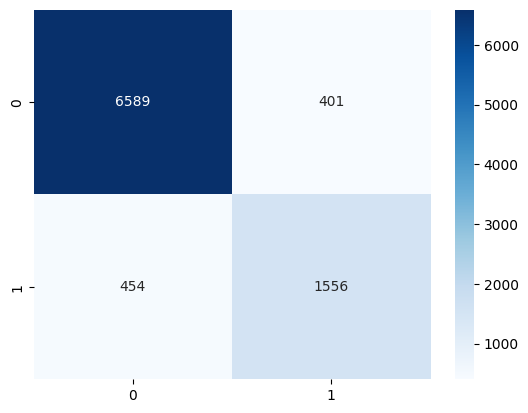

In [396]:
adboost=AdaBoostClassifier()
model_adboost_RFECV=RFECV(estimator=adboost,cv=8,min_features_to_select=10)
model_adboost_RFECV.fit(X_train_scaled,y_train)
y_pred_adboost=model_adboost_RFECV.predict(X_test_scaled_pd)
print(classification_report(y_test,y_pred_adboost))
sns.heatmap(confusion_matrix(y_test,y_pred_adboost),annot=True,cmap="Blues",fmt="d")


robust scaler

Robust Scaler
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      6990
           1       0.89      0.80      0.84      2010

    accuracy                           0.93      9000
   macro avg       0.92      0.89      0.90      9000
weighted avg       0.93      0.93      0.93      9000



<Axes: >

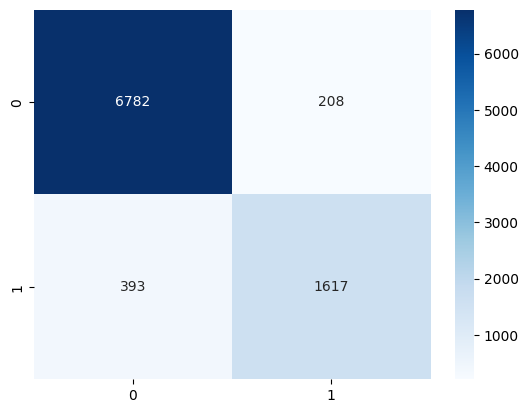

In [51]:

print("Robust Scaler")

X_train_scaled, X_test_scaled_pd=Scaling_function(X_train,X_test,RobustScaler)
xgb=XGBClassifier()
model_XGB_RFE=RFECV(estimator=xgb,cv=10,min_features_to_select=8,step=10)
model_XGB_RFE.fit(X_train_scaled,y_train)
y_pred_XGB=model_XGB_RFE.predict(X_test_scaled_pd)
print(classification_report(y_test,y_pred_XGB))
sns.heatmap(confusion_matrix(y_test,y_pred_XGB),annot=True,cmap="Blues",fmt="d")


hyperparamter tuning


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.feature_selection import SelectKBest,chi2,RFECV
from sklearn.model_selection import GridSearchCV

In [41]:
X_train_scaled,X_test_scaled_pd=Scaling_function(X_train,X_test,RobustScaler)
models={
    "LogisticRegression": LogisticRegression(),
    "SVC":SVC(),
    "XGBClassifier":XGBClassifier(),
    "RandomForestClassifier":RandomForestClassifier(),
    "DecisionTreeClassifier":DecisionTreeClassifier(),
    "AdaBoostClassifier":AdaBoostClassifier()
}

paramters={
    "LogisticRegression":{
        "C":[0.1,1,10,20,30,40,50,100],
        "penalty":["l1","l2"],
        "solver":["liblinear","saga"]
    },
    "SVC":{
        "C":[0.1,0,0.5,1],
        "kernel":["linear","poly","rbf"],
        "gamma":["scale","auto"],
    }
    ,
    "XGBClassifier":{
        "n_estimators":[100,200,300]
        ,"learning_rate":[0.1,0.2,0.3,0.01,0.02]
    },
    "RandomForestClassifier":{
        "n_estimators":[100,200,300]
        ,"max_depth":[5,10,15]
    },
    "DecisionTreeClassifier":{
        "max_depth":[5,10,15,20]
        ,"min_samples_split":[2,5,10]
    },
    "AdaBoostClassifier":{
        "n_estimators":[100,200,250],
        "learning_rate":[0.01,0.1,0.2,0.3]
    }
}

best_model={}
for name,model in models.items():
  grid_search=GridSearchCV(model,paramters[name],cv=5,scoring="accuracy",n_jobs=-1)
  grid_search.fit(X_train_scaled,y_train)
  best_model[name]=grid_search.best_estimator_


In [43]:
for name,model in best_model.items():
  y_pred=model.predict(X_test_scaled_pd)
  print(name)
  print(classification_report(y_test,y_pred))

  print("*"*60)

LogisticRegression
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      6990
           1       0.77      0.73      0.75      2010

    accuracy                           0.89      9000
   macro avg       0.84      0.83      0.84      9000
weighted avg       0.89      0.89      0.89      9000

************************************************************
SVC
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      6990
           1       0.83      0.71      0.77      2010

    accuracy                           0.90      9000
   macro avg       0.88      0.84      0.85      9000
weighted avg       0.90      0.90      0.90      9000

************************************************************
XGBClassifier
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      6990
           1       0.89      0.81      0.85      2010

    accuracy           

In [48]:
# from sklearn.feature_selection import RFE

# X_train_scaled,X_test_scaled=Scaling_function(X_train,X_test,StandardScaler)
# best_model2={}
# # Step 1: Use RFE with base model
# rfe = RFE(estimator=models[name], n_features_to_select=8)
# X_train_rfe = rfe.fit_transform(X_train_scaled, y_train)


# # Step 2: Now tune best model with GridSearchCV
# grid_search = GridSearchCV(estimator=models[name],
#                            param_grid=paramters[name],
#                            cv=10,
#                            scoring='accuracy',
#                            n_jobs=-1)
# grid_search.fit(X_train_rfe, y_train)

# # Save final model
# best_model2[name] = grid_search.best_estimator_

#   # print(name)
#   # print("Selected features:", model_RFE.support_)
#   # print("Feature ranking:", model_RFE.ranking_)
#   # print("Training Accuracy:", model_RFE.score(X_train_scaled, y_train))
#   # print("Testing Accuracy:", model_RFE.score(X_test_scaled_pd, y_test))
# print("*"*60)

************************************************************


In [50]:
# for name,model in best_model2.items():
#   y_pred=model.predict(X_test_scaled)
#   print(name)
#   print(classification_report(y_test,y_pred))

#   print("*"*60)

ValueError: X has 13 features, but LogisticRegression is expecting 8 features as input.